In [46]:
import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("code")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")


import Chronocell
from impute_protein import *
from protein_from_RNA import *

In [47]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [48]:
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Names of genes in Chronocell object
genes = pd.read_csv(f"data/{prefix}.csv")

In [49]:
sampleinfo = pd.read_csv(f"data/{prefix}_sampleinfo_barcode_level.csv")

# orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")
expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

In [50]:
# Subset to genes of interest

# orig_corr = orig_corr.loc[orig_corr['Gene'].isin(expr_ADT_imputed.columns)]

In [51]:
t = traj.t
Q = traj.Q[:, 0, :] 

In [52]:
# Make sure order of cells matches

In [53]:
expr_ADT_imputed.index = sampleinfo['Cell_ID']

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [54]:
expr_RNA = expr_RNA.loc[expr_ADT_imputed.index]
expr_ADT = expr_ADT.loc[expr_ADT_imputed.index]

In [55]:
np.all(expr_ADT_imputed.index == expr_ADT.index)

np.True_

In [56]:
np.all(expr_ADT_imputed.index == expr_RNA.index)

np.True_

In [57]:
# Order cells by their inferred place in time

In [58]:
Q_max_idx = np.argmax(Q, axis=1)

cell_order_idx = np.argsort(Q_max_idx)
cell_index = expr_ADT.index[cell_order_idx]

expr_ADT_ordered = expr_ADT.loc[cell_index]
expr_RNA_ordered = expr_RNA.loc[cell_index]
expr_ADT_imputed_ordered = expr_ADT_imputed.loc[cell_index]

In [59]:
# Time point per cell for plotting

t_per_cell = t[np.sort(Q_max_idx)]

In [60]:
prot = "CD63"
gene = "Cd63"

In [61]:
# Load imputed RNA for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw = pickle.load(f)
    
X_bw_ordered = X_bw[cell_order_idx, :]
Q_max_idx_ordered = Q_max_idx[cell_order_idx]

In [62]:
# Subset to end cell to get whole trajectory
end_cells_idx = np.where(Q_max_idx_ordered == 99)[0]
end_cells_idx

array([20199, 20200, 20201, ..., 21322, 21323, 21324])

In [63]:
# Plot imputed RNA and protein for various cells

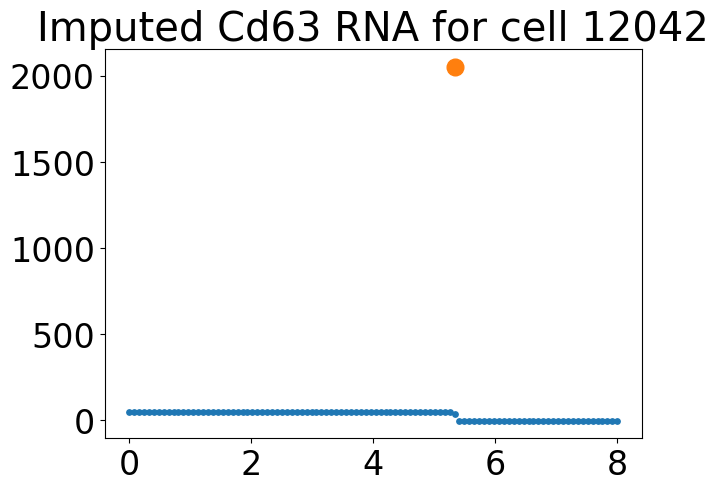

In [64]:
idx = expr_ADT_imputed_ordered.loc[:, gene].argmax()

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)
plt.scatter(
    t[Q_max_idx_ordered[idx]],
    expr_ADT_imputed_ordered.iloc[idx].loc[gene]
)
plt.title(f"Imputed {gene} RNA for cell {idx}");

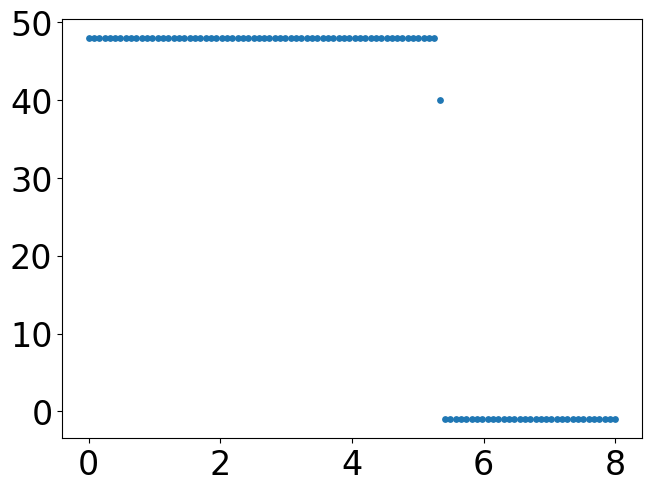

In [65]:
idx = expr_ADT_imputed_ordered.loc[:, gene].argmax()

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)

Text(0.5, 1.0, 'Imputed Cd63 RNA for cell 21241')

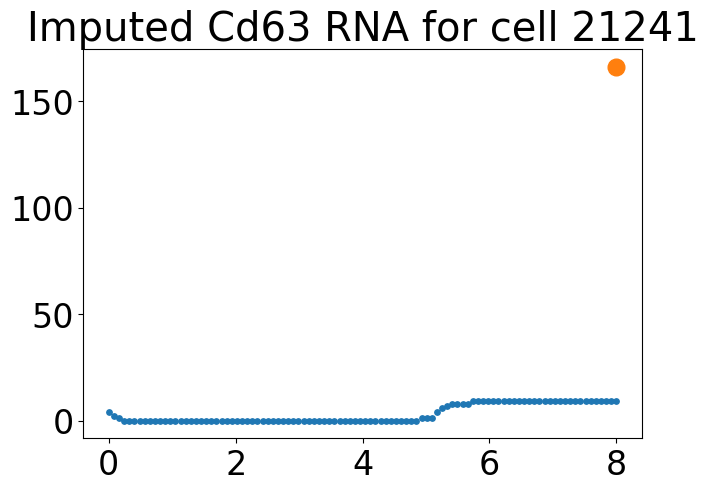

In [66]:
idx = -1

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)
plt.scatter(
    t[Q_max_idx_ordered[idx]],
    expr_ADT_imputed_ordered.iloc[idx].loc[gene]
)
plt.title(f"Imputed {gene} RNA for cell {cell_order_idx[idx]}")

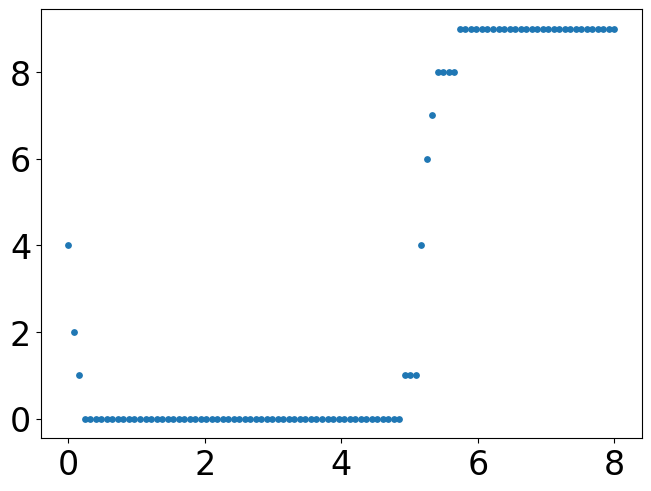

In [67]:
idx = -1

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)

In [68]:
recon_RNA = X_bw_ordered[:, :5]
recon_RNA[recon_RNA >= 0]

array([ 3, 17, 11, ...,  1,  0,  0])

In [69]:
t[5]

np.float64(0.4040404040404041)

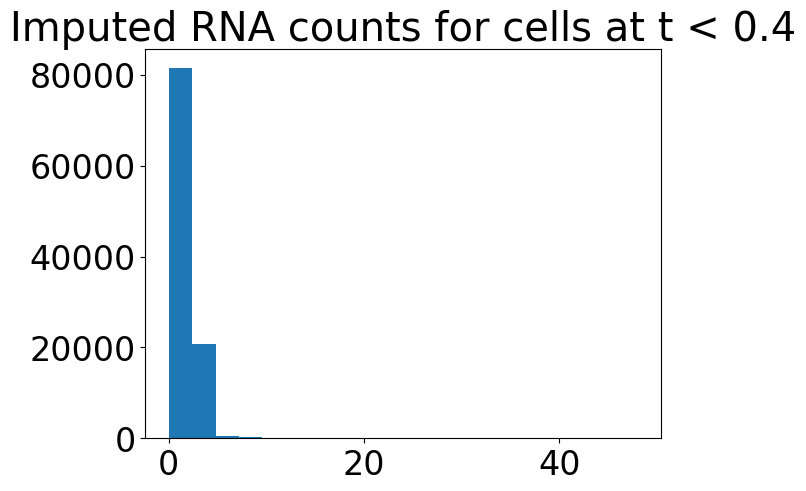

In [70]:
plt.hist(recon_RNA[recon_RNA >= 0], bins=20);
plt.title(f"Imputed RNA counts for cells at t < {np.round(t[5], 2)}");

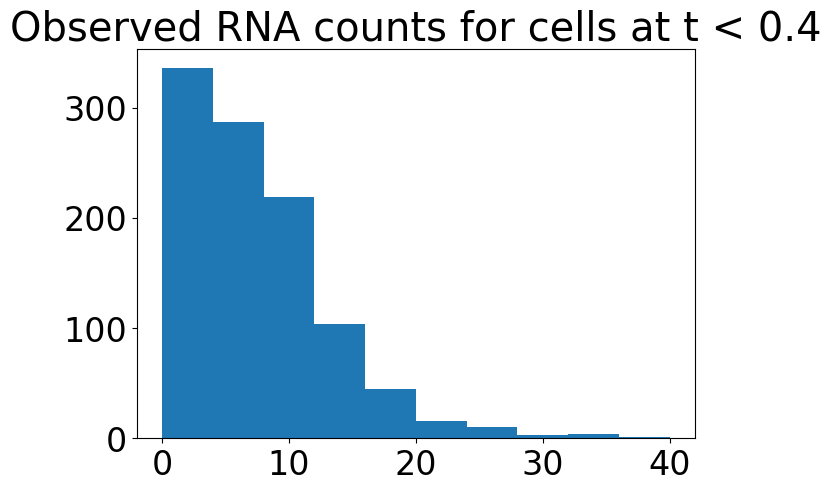

In [71]:
plt.hist(expr_RNA_ordered[gene][t_per_cell < 0.4]);
plt.title("Observed RNA counts for cells at t < 0.4");

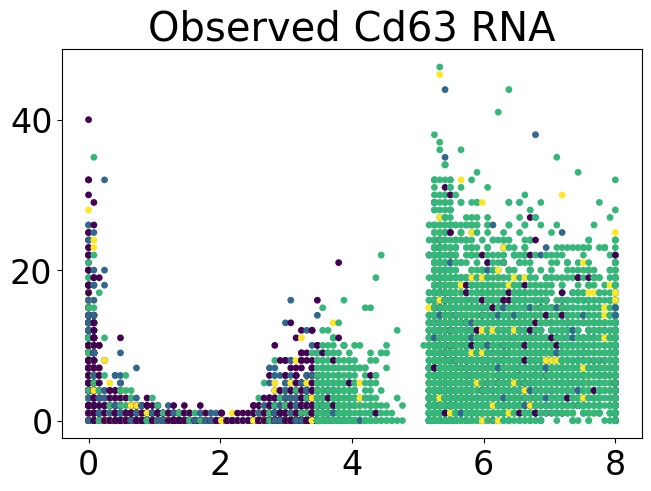

In [72]:
plt.scatter(
    t_per_cell,
    expr_RNA_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} RNA");

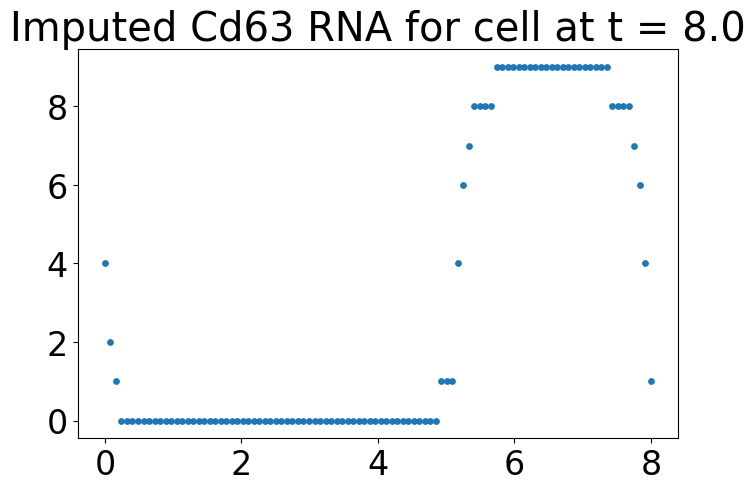

In [73]:
idx = -92 # expr_ADT_imputed_ordered.loc[:, gene].argmax()

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)
plt.title(f"Imputed {gene} RNA for cell at t = {np.round(t_per_cell[idx], 2)}");

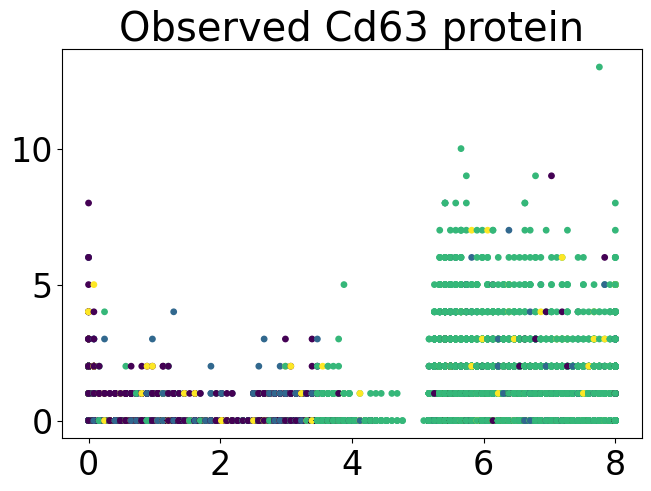

In [74]:
plt.scatter(
    t_per_cell,
    expr_ADT_ordered[prot],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} protein");

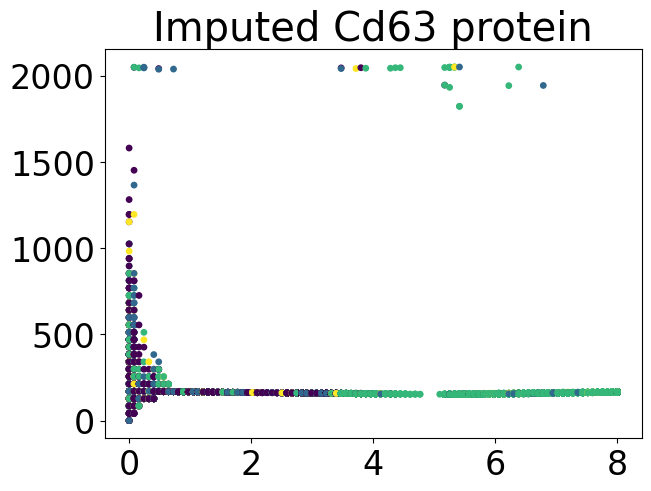

In [75]:
plt.scatter(
    t_per_cell,
    expr_ADT_imputed_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Imputed {gene} protein");

In [76]:
# Now let's try simulating protein using reconstructed RNA and kinetic parameters for the working gene

In [77]:
tau = traj.tau # State transition times (global)
topo = traj.topo
true_t = traj.t
true_l = np.repeat(0, len(t)) 

In [78]:
# Get deg. rate for gene of interst

data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)
    
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)

half_life_cols = [col for col in df.columns if "Half-life" in col]
df_deg = np.log(2)/df[half_life_cols]
median_deg = np.nanmedian(df_deg, axis=1)

In [79]:
deg_rate = median_deg[np.where(df['Gene'] == gene)[0][0]]
deg_rate

np.float64(0.023397355708481997)

In [80]:
phi = np.zeros((1, 2))
phi[:,0] = 1
phi[:,-1] = deg_rate

In [ ]:
# Load previously imputed RNA for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_S = pickle.load(f)
    
file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_U_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_U = pickle.load(f)

In [82]:
X_bw_S_ordered = X_bw_S[cell_order_idx, :]
X_bw_U_ordered = X_bw_U[cell_order_idx, :]

# How do my imputed estimates compare to what I imputed earlier?

In [97]:
def simulate_protein_from_RNA(Y, topo, true_t, true_l, phi, step_size, random_seed=0):
    ## phi: Protein params
    np.random.seed(random_seed)
    
    L = len(topo) # No. lineages
    n = Y.shape[0] // L # No. cells per lineage
    p = Y.shape[1] # No. genes
    
    y0 = Y[0, :, 1] # RNA abundance per gene at state 0
    ss_rate = phi[:, 0] / phi[:, -1] # Steady-state protein production rate = transl_rate/deg_rate
    p0 = ss_rate * y0 # Initial protein abundance assuming steady-state
    print("y0:", y0)
   
    # Protein production paramters:
    transl_rates = phi[:, 0].T
    deg_rates = phi[:, -1].reshape((1, -1))
    
    P = np.zeros((n*L, p))
    
    for l in range(L):
        t_l = true_t[true_l == l] # Time points/cells in lineage l     
        dt = np.repeat(step_size, len(t_l)) # np.diff(t_l, prepend=-t_l[1]) # Time step size for each cell along the trajectory
        t_l = t_l.reshape((-1, 1)) 
        y_l = Y[l*n:(l+1)*n, :, 1] # Spliced RNAs for lineage l
        
        p_l = p0 * np.exp(-deg_rates * t_l) # Pre-existing protein that has not yet degraded
        print("p_old:", p_l[-1])
        
        t_diff = t_l - t_l.T # Rows = target time; columns = past times; e.g. t_diff[m, i] = time difference between t_m and t_i 
        decay_matrix = np.exp(-t_diff[:, :, None] * deg_rates) # Decay_matrix[m, i, p] = decay factor for protein abundance at t_m from RNA available at t_i for gene p
        mask = (t_diff >= 0)[:, :, None]
        mask = np.broadcast_to(mask, decay_matrix.shape)
        decay_matrix = np.where(mask, decay_matrix, 0) # Protein abundance at time t_m can't come from RNA at time t_i > t_m
        
        y_l_dt = y_l * dt[:, None] # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation)
        # Note to self: protein produced from RNA from time t = m can only be produced during the interval it was measured over, hence: scale RNA contribution at that time step by its time step size
        protein_contrib = (decay_matrix * y_l_dt[None, :, :]).sum(axis=1) # Integrate RNA counts still surviving up to each time point
        # Note to self: protein_contrib[target_idx, gene_idx] = np.sum(decay_matrix[target_time, :(target_time + 1), gene_idx] * y_l_dt[None, :(target_time + 1), gene_idx])
        P[l*n:(l+1)*n] = p_l + transl_rates * protein_contrib # Protein abundance in each cell = pre-existing protein + newly synthesized protein
        print("p_new:", (transl_rates * protein_contrib)[-1])
        print("P:", P[l*n:(l+1)*n][-1])
         
    P_observed = np.random.poisson(P)
        
    return P_observed, P, y0

In [98]:
step_size = t[1] - t[0]

In [99]:
subset_idx = np.where(t_per_cell <= 8)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [17.]
p_old: [726.57783263]
p_new: [1.37373737]
P: [727.95157001]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [4.]
p_old: [170.95949003]
p_new: [0.32323232]
P: [171.28272235]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [214.10340294]
Inferfed t: 0.0
y0: [12.]
p_old: [512.87847009]
p_new: [0.96969697]
P: [513.84816706]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [13.]
p_old: [555.6183426]
p_new: [1.05050505]
P: [556.66884765]
Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]


In [100]:
expr_ADT_imputed_ordered[gene].iloc[subset_idx]

Cell_ID
CACACAATCGGACAAG-2    128
CACATGAGTCGTTATG-2    726
CACATGATCGAGAAAT-2    470
GCATCTCGTGAGCAGT-2    170
GCGAGAAAGAGGGCGA-2    384
                     ... 
TTTATGCTCCTTTGAT-2    167
TTTGATCAGCACTCAT-2    166
TTTGACTGTTTCGTAG-2    165
TTTCCTCTCAAAGCCT-2    166
TTTCAGTTCGAGCCTG-2    166
Name: Cd63, Length: 21325, dtype: int64

In [101]:
np.corrcoef(expr_ADT_imputed_ordered[gene].iloc[subset_idx], P_curr)

array([[1.        , 0.99998508],
       [0.99998508, 1.        ]])

## Almost identitical. Which means that imputation code was fine.

# Now let's compare protein abundance estimates at t = 0 from early cells and late cells

## I'm wondering: why are the protein estimates so high for cells at early time points, but considerably lower for cells at later time points? 

In [93]:
subset_idx = np.where(t_per_cell <= 0.3)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [17.]
p_old: [726.57783263]
p_new: [1.37373737]
P: [727.95157001]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [4.]
p_old: [170.95949003]
p_new: [0.32323232]
P: [171.28272235]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [214.10340294]
Inferfed t: 0.0
y0: [12.]
p_old: [512.87847009]
p_new: [0.96969697]
P: [513.84816706]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [13.]
p_old: [555.6183426]
p_new: [1.05050505]
P: [556.66884765]
Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]


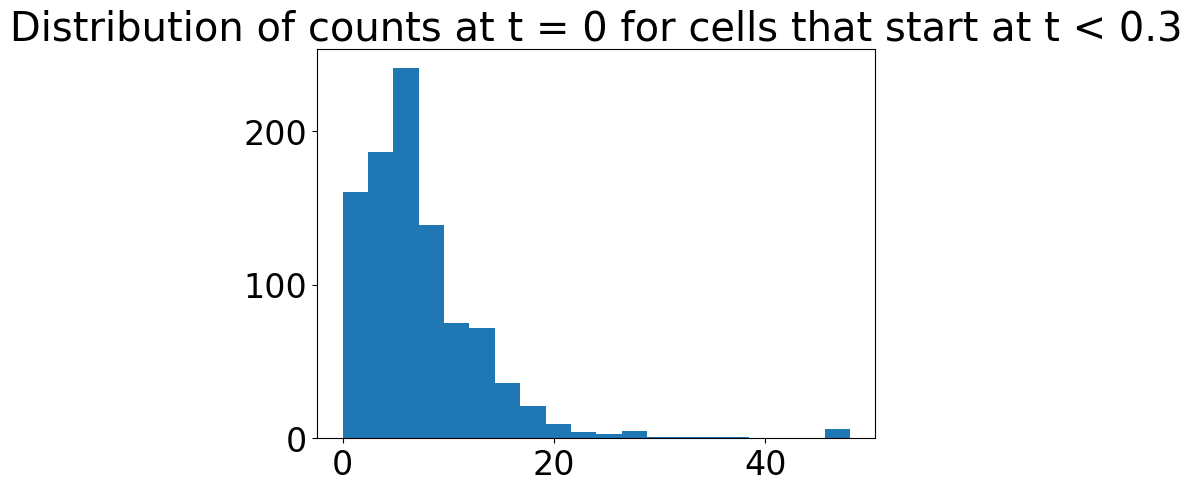

In [94]:
plt.hist(y0_imputed, bins=20);
plt.title("Distribution of counts at t = 0 for cells that start at t < 0.3");

In [95]:
subset_idx = np.where(t_per_cell > 6)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.73374818]
P: [155.37194854]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [7.13717831]
P: [155.77537867]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [8.10413382]
P: [156.74233419]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [8.5074119]
P: [157.14561226]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.6529401]
P: [155.29114046]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [7.13717831]
P: [155.77537867]
Inferfed t: 

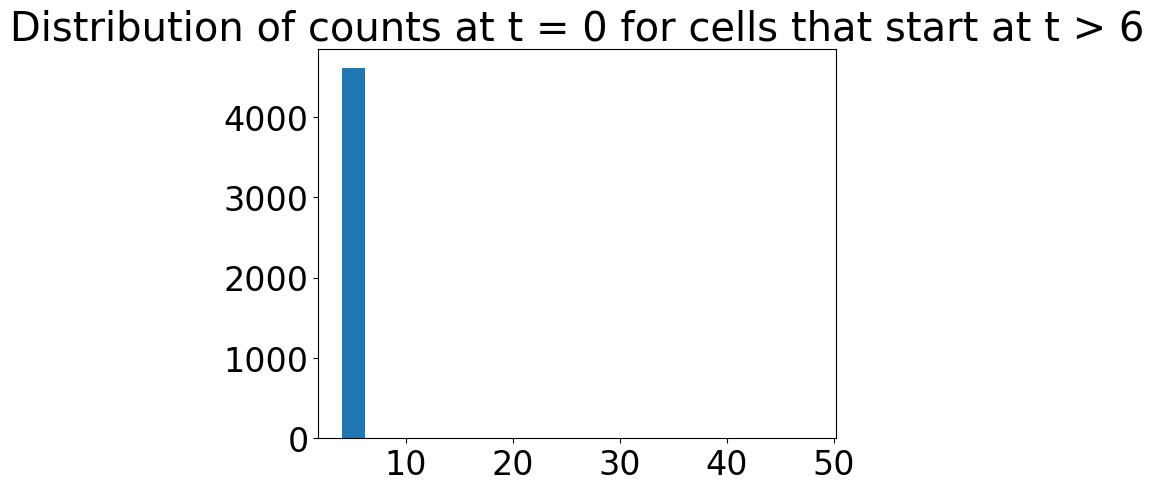

In [96]:
plt.hist(y0_imputed, bins=20);
plt.title("Distribution of counts at t = 0 for cells that start at t > 6");

### It looks like the issue is that cells from later in the trajectory all have RNA abundances that are the same since they revert to the mean by that point. Cells earlier in the trajectory still retain some variability, so many more cells have larger starting RNA abundances, hence higher imputed protein levels